In [1]:
import pandas as pd
import plotnine as p9
import numpy as np
import scanpy as sc

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mplpatches

In [3]:
p9.options.dpi=300
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype']='none'

In [5]:
OAK_multiome_ATAC_FA_classification=pd.read_csv(OAK_multiomeATAC_directoryname+'/FAWash2/outs/singlecell.csv',header=0) 

In [6]:
OAK_multiome_ATAC_FA_cells=OAK_multiome_ATAC_FA_classification[OAK_multiome_ATAC_FA_classification['is_mm10_cell_barcode']+OAK_multiome_ATAC_FA_classification['is_GRCh38_cell_barcode']>0]

In [7]:
conditions = [
    (OAK_multiome_ATAC_FA_cells['cell_id'].str.contains('mm10')) & (OAK_multiome_ATAC_FA_cells['cell_id'].str.contains('GRCh38')),
    (OAK_multiome_ATAC_FA_cells['cell_id'].str.contains('GRCh38')),
    (OAK_multiome_ATAC_FA_cells['cell_id'].str.contains('mm10'))
    ]

values=['Multiplet_obs','GRCh38','mm10']

In [8]:
OAK_multiome_ATAC_FA_cells['call']=np.select(conditions,values)

/local/50469756/ipykernel_2706/1860611158.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [9]:
OAK_multiome_ATAC_FA_cells['TSS_pct']=OAK_multiome_ATAC_FA_cells['TSS_fragments']/OAK_multiome_ATAC_FA_cells['passed_filters']
#passed_filters means number of non-duplicate, usable read-pairs i.e. "fragments"

/local/50469756/ipykernel_2706/878573861.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [10]:
OAK_multiome_ATAC_ME_classification=pd.read_csv(OAK_multiomeATAC_directoryname+'/MethWash2/outs/singlecell.csv',header=0) 

In [11]:
OAK_multiome_ATAC_ME_cells=OAK_multiome_ATAC_ME_classification[OAK_multiome_ATAC_ME_classification['is_mm10_cell_barcode']+OAK_multiome_ATAC_ME_classification['is_GRCh38_cell_barcode']>0]

In [12]:
conditions = [
    (OAK_multiome_ATAC_ME_cells['cell_id'].str.contains('mm10')) & (OAK_multiome_ATAC_ME_cells['cell_id'].str.contains('GRCh38')),
    (OAK_multiome_ATAC_ME_cells['cell_id'].str.contains('GRCh38')),
    (OAK_multiome_ATAC_ME_cells['cell_id'].str.contains('mm10'))
    ]

values=['Multiplet_obs','GRCh38','mm10']

In [13]:
OAK_multiome_ATAC_ME_cells['call']=np.select(conditions,values)

/local/50469756/ipykernel_2706/1313176237.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [14]:
OAK_multiome_ATAC_ME_cells['TSS_pct']=OAK_multiome_ATAC_ME_cells['TSS_fragments']/OAK_multiome_ATAC_ME_cells['passed_filters']

/local/50469756/ipykernel_2706/2349905484.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [15]:
Control_multiome_ATAC_K562=pd.read_csv(Control10x_multiome_ATAC_directoryname+'/outs/per_barcode_metrics.csv',header=0) 

In [16]:
Control_multiome_ATAC_K562_cells=Control_multiome_ATAC_K562[Control_multiome_ATAC_K562['is_cell']>0]

In [17]:
Control_multiome_ATAC_K562_cells['TSS_pct']=Control_multiome_ATAC_K562_cells['atac_TSS_fragments']/Control_multiome_ATAC_K562_cells['atac_fragments']
#atac_fragments means number of non-duplicate, usable read pairs that map to the nuclear genome

/local/50469756/ipykernel_2706/3006613143.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [18]:
df_OAK_ME_K562=OAK_multiome_ATAC_ME_cells[OAK_multiome_ATAC_ME_cells['call']=='GRCh38'][['barcode','total','passed_filters','TSS_fragments','peak_region_fragments']]

In [19]:
df_OAK_FA_K562=OAK_multiome_ATAC_FA_cells[OAK_multiome_ATAC_FA_cells['call']=='GRCh38'][['barcode','total','passed_filters','TSS_fragments','peak_region_fragments']]

In [20]:
df_OAK_ME_K562['experiment']='OAK_MeOH'

In [21]:
df_OAK_FA_K562['experiment']='OAK_FA'

In [22]:
df_10x_K562=Control_multiome_ATAC_K562_cells[['barcode','atac_raw_reads','atac_fragments','atac_TSS_fragments','atac_peak_region_fragments']]

In [23]:
df_10x_K562['experiment']='Chromium'

/local/50469756/ipykernel_2706/1094343543.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [24]:
df_OAK_ME_K562.columns=df_10x_K562.columns
df_OAK_FA_K562.columns=df_10x_K562.columns

In [25]:
df_compare=pd.concat([df_10x_K562,df_OAK_FA_K562,df_OAK_ME_K562],ignore_index=True) 

In [26]:
df_compare['TSS_pct']=(df_compare['atac_TSS_fragments']/df_compare['atac_fragments'])*100

In [27]:
df_compare['ATACfragmentX1000']=df_compare['atac_fragments']/1000

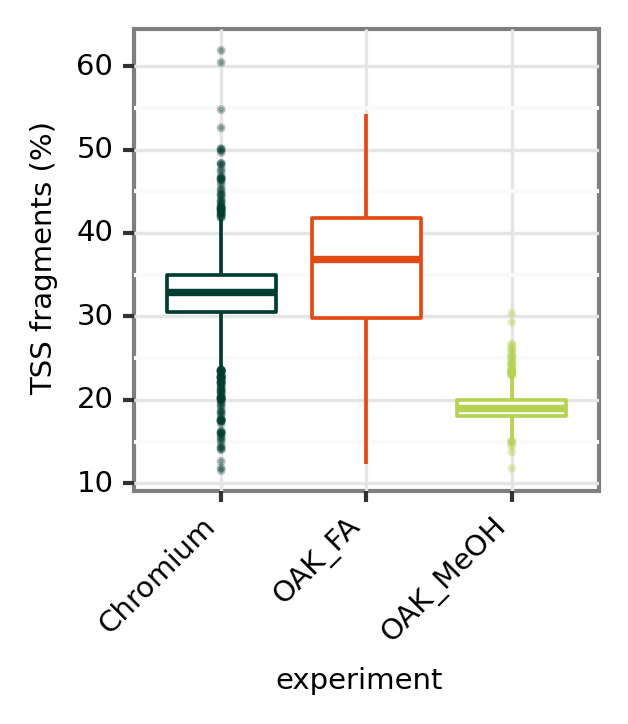

In [28]:
plot=p9.ggplot(data=df_compare,
               mapping=p9.aes(x='experiment',y='TSS_pct',color="experiment")
              )
pl=plot+ p9.geom_boxplot(outlier_alpha=0.3,outlier_size=0.2, show_legend=False) \
+ p9.themes.theme_bw() \
+ p9.theme(axis_text_x=p9.element_text(colour="black",angle = 45, hjust = 1)) \
+ p9.theme(axis_text_y=p9.element_text(colour="black")) \
+ p9.theme(text=p9.element_text(size=7),legend_position=(0.71,0.75),legend_title=p9.element_blank(),legend_direction='vertical',legend_key=p9.element_blank(),legend_key_size=5) \
+ p9.scale_color_manual(values = {'OAK_FA':'#E24B15','Chromium':'#003C30','OAK_MeOH':'#B5D251'}) \
+ p9.labels.ylab('TSS fragments (%)') \
+ p9.theme(figure_size=(2,2)) # inch
fig=pl.draw()
fig.set_size_inches(2, 2)
fig.savefig('OAK_multiome_ATAC_TSS.svg',format='svg',dpi=300,bbox_inches='tight')  

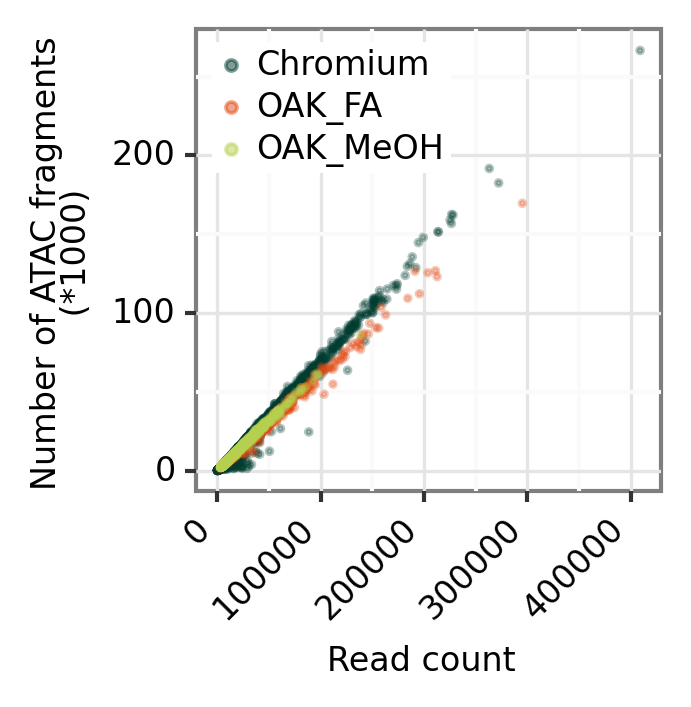

<ggplot: (2932143271006)>

In [29]:
plot=p9.ggplot(data=df_compare,
               mapping=p9.aes(x='atac_raw_reads',y='ATACfragmentX1000',color="experiment")
              )
plot+ p9.geom_point(alpha=0.3,size=0.3) \
+ p9.themes.theme_bw() \
+ p9.theme(axis_text_x=p9.element_text(colour="black",angle = 45, hjust = 1)) \
+ p9.theme(axis_text_y=p9.element_text(colour="black")) \
+ p9.theme(text=p9.element_text(size=8),legend_position=(0.35,0.75),legend_title=p9.element_blank(),legend_direction='vertical',legend_key=p9.element_blank(),legend_key_size=5,legend_box_margin=0) \
+ p9.guides(color = p9.guide_legend(override_aes={'size' :1,'alpha':0.5 })) \
+ p9.scale_color_manual(values = {'OAK_FA':'#E24B15','Chromium':'#003C30','OAK_MeOH':'#B5D251'}) \
+ p9.labels.ylab('Number of ATAC fragments \n (*1000)') \
+ p9.labels.xlab('Read count') \
+ p9.theme(figure_size=(2,2)) # inch

/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/plotnine/layer.py:411: PlotnineWarning: geom_point : Removed 53 rows containing missing values.


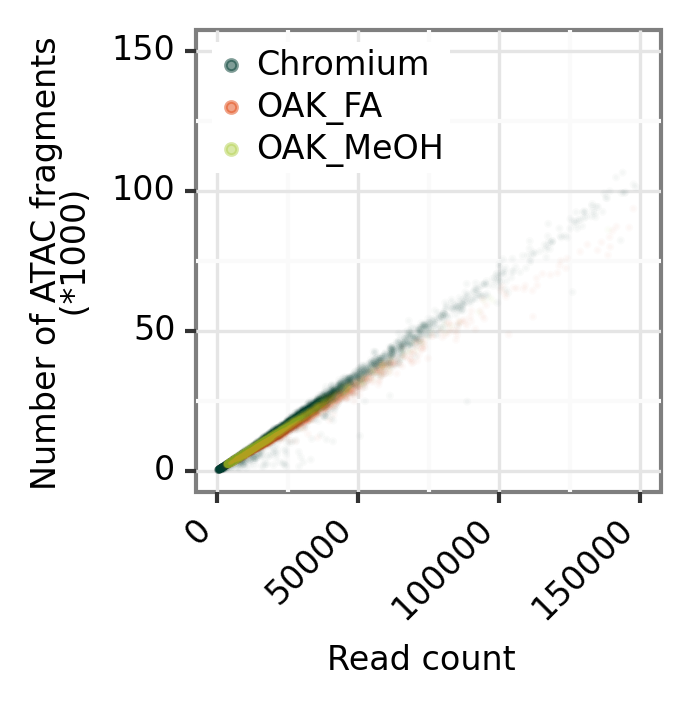

<ggplot: (2932143265859)>

In [28]:
plot=p9.ggplot(data=df_compare,
               mapping=p9.aes(x='atac_raw_reads',y='ATACfragmentX1000',color="experiment")
              )
plot+ p9.geom_point(alpha=0.02,size=0.1) \
+ p9.themes.theme_bw() \
+ p9.theme(axis_text_x=p9.element_text(colour="black",angle = 45, hjust = 1)) \
+ p9.theme(axis_text_y=p9.element_text(colour="black")) \
+ p9.theme(text=p9.element_text(size=8),legend_position=(0.35,0.75),legend_title=p9.element_blank(),legend_direction='vertical',legend_key=p9.element_blank(),legend_key_size=5,legend_box_margin=0) \
+ p9.guides(color = p9.guide_legend(override_aes={'size' :1,'alpha':0.5 })) \
+ p9.scale_color_manual(values = {'OAK_FA':'#E24B15','Chromium':'#003C30','OAK_MeOH':'#B5D251'}) \
+ p9.labels.ylab('Number of ATAC fragments \n (*1000)') \
+ p9.labels.xlab('Read count') \
+ p9.xlim(0,150000) \
+ p9.ylim(0,150) \
+ p9.theme(figure_size=(2,2)) # inch

In [34]:
plot=p9.ggplot(data=df_compare,
               mapping=p9.aes(x='atac_raw_reads',y='ATACfragmentX1000',color="experiment")
              )
plotsave=plot+ p9.geom_point(alpha=0.02,size=0.1) \
+ p9.themes.theme_bw() \
+ p9.theme(axis_text_x=p9.element_text(colour="black",angle = 45, hjust = 1)) \
+ p9.theme(axis_text_y=p9.element_text(colour="black")) \
+ p9.theme(text=p9.element_text(size=8),legend_position=(0.35,0.75),legend_title=p9.element_blank(),legend_direction='vertical',legend_key=p9.element_blank(),legend_key_size=5,legend_box_margin=0) \
+ p9.guides(color = p9.guide_legend(override_aes={'size' :1,'alpha':0.5 })) \
+ p9.scale_color_manual(values = {'OAK_FA':'#E24B15','Chromium':'#003C30','OAK_MeOH':'#B5D251'}) \
+ p9.labels.ylab('Number of ATAC fragments \n (*1000)') \
+ p9.labels.xlab('Read count') \
+ p9.xlim(0,150000) \
+ p9.ylim(0,150) \
+ p9.theme(figure_size=(2,2)) # inch
fig=plotsave.draw()
fig.set_size_inches(2, 2)
points = fig.axes[0].collections[0]
points.set_rasterized(True)
fig.savefig('OAK_multiome_ATACfragments_2fixatives.svg',format='svg',dpi=300,bbox_inches='tight')  

/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/plotnine/layer.py:411: PlotnineWarning: geom_point : Removed 53 rows containing missing values.


In [29]:
df_compare

,barcode,atac_raw_reads,atac_fragments,atac_TSS_fragments,atac_peak_region_fragments,experiment,TSS_pct,ATACfragmentX1000
0,AAACATGCAAGCCAGA-1,36476,20530,7527,13913,Chromium,36.663419,20.530
1,AAACATGCAAGGACCA-1,18701,12535,3874,7529,Chromium,30.905465,12.535
2,AAACATGCAATCCCTT-1,9445,3377,1248,1685,Chromium,36.955878,3.377
3,AAACATGCACACAATT-1,27745,17779,6727,12134,Chromium,37.836774,17.779
4,AAACATGCATTCCTCG-1,3175,2150,645,1307,Chromium,30.000000,2.150
...,...,...,...,...,...,...,...,...
9217,TTTGGCCAGATTCTGT-1,4785,3119,599,2986,OAK_MeOH,19.204873,3.119
9218,TTTGGTTAGGCGCAGT-1,17222,11150,2320,10769,OAK_MeOH,20.807175,11.150
9219,TTTGGTTAGGTATGTA-1,16696,10452,2098,10036,OAK_MeOH,20.072713,10.452
9220,TTTGGTTAGGTGGAAA-1,7239,4571,1045,4468,OAK_MeOH,22.861518,4.571


In [30]:
df_compare.to_csv(data_dir+'Fig1ik.csv',header=True,index=False)